In [1]:
import numpy as np
from scipy.stats import norm
from scipy.stats import skewnorm
import statsmodels.api as sm

from tqdm.notebook import tqdm
import pickle
import pandas as pd
import os

import sys 
sys.path.insert(0, '../src/')

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

In [2]:
dtype = 'float32'

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:
a = 0.5
b = 1.0

In [5]:
N = 500 # dataset size
m = 10  # subsample size
n = 500 # training size
J = 50  # number of subsamples

In [6]:
Xs = np.sort(np.random.uniform(low=0.0, high=a, size=N)).astype(dtype).reshape(-1,1)
new_Xs = np.sort(np.random.uniform(low=0.0, high=b, size=N)).astype(dtype).reshape(-1,1)

v = 0.1*Xs
new_v = 0.1*new_Xs

epsilon = np.array([np.random.normal(0, v[i]) for i in range(N)])
new_epsilon = np.array([np.random.normal(0, new_v[i]) for i in range(N)])

beta = 1.0
Ys = beta * Xs + epsilon.reshape(-1,1)
new_Ys = beta * new_Xs + new_epsilon.reshape(-1,1)

In [7]:
print(Xs.shape)
print(Ys.shape)
print(new_Xs.shape)
print(new_Ys.shape)

(500, 1)
(500, 1)
(500, 1)
(500, 1)


In [8]:
# shuffling
idx = np.random.choice(N, N, replace=False)
Xs = torch.Tensor(Xs[idx])
Ys = torch.Tensor(Ys[idx])
v = torch.Tensor(v[idx])

idx = np.random.choice(N, N, replace=False)
new_Xs = torch.Tensor(new_Xs[idx])
new_Ys = torch.Tensor(new_Ys[idx])
new_v = torch.Tensor(new_v[idx])

In [9]:
print(Xs.shape)
print(Ys.shape)
print(new_Xs.shape)
print(new_Ys.shape)

torch.Size([500, 1])
torch.Size([500, 1])
torch.Size([500, 1])
torch.Size([500, 1])


In [10]:
d = Xs.shape[1] # data dimension
d

1

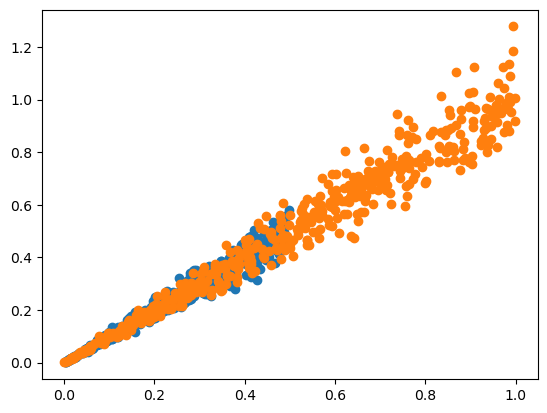

In [11]:
plt.scatter(Xs[:,0], Ys[:,0])
plt.scatter(new_Xs[:,0], new_Ys[:,0])
plt.show()

In [12]:
# VIDS here
import VIDS_my.VIDS_my as vids

In [13]:
# define the embedding network 

repr_dim = 8

# g = nn.Sequential(
#     nn.Linear(d, repr_dim)
# )

In [14]:
# pred_model = nn.Sequential(
#     g,
#     nn.Linear(repr_dim, 1, bias=False)
# )

In [15]:
# loss_fn = torch.nn.MSELoss()
# optim = torch.optim.Adam(pred_model.parameters(), lr=1e-3)

In [16]:
# from torch.utils.data import TensorDataset, DataLoader

# batch_size = 64

# dataset = TensorDataset(Xs, Ys)
# dataloader = DataLoader(
#     dataset,
#     batch_size=batch_size,
#     shuffle=True
# )

In [17]:
# dataset = TensorDataset(Xs, Ys)
# dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# num_epochs = 1000

# for epoch in range(num_epochs):
#     pred_model.train()
#     epoch_loss = 0.0

#     for X_batch, y_batch in dataloader:
#         y_pred = pred_model(X_batch)
#         loss = loss_fn(y_pred, y_batch)

#         optim.zero_grad()
#         loss.backward()
#         optim.step()

#         epoch_loss += loss.item() * X_batch.size(0)

#     epoch_loss /= len(dataset)

In [18]:
# with torch.no_grad():
#     vanilla_predictions = np.array(pred_model(new_Xs)).flatten()

In [19]:
# plt.scatter(new_Xs.numpy(), vanilla_predictions)
# plt.scatter(Xs.numpy(), Ys.numpy())
# plt.show()

In [20]:
# class vids_net(nn.Module):
#     def __init__(self, representation_dim):
#         super().__init__()

#         # Input size is 8 + 8 = 16 due to concatenation
#         self.fc1 = nn.Linear(16, 64 * representation_dim)
#         self.fc2 = nn.Linear(64 * representation_dim, 32 * representation_dim)
#         self.fc3 = nn.Linear(32 * representation_dim, 16 * representation_dim)
#         self.fc4 = nn.Linear(16 * representation_dim, 8 * representation_dim)
#         self.fc5 = nn.Linear(8 * representation_dim, 4 * representation_dim)
#         self.fc6 = nn.Linear(4 * representation_dim, 2 * representation_dim)

#     def forward(self, gXstar_inputs):
#         # Concatenate along feature dimension
#         # x = torch.cat([gXstar_inputs, gX_summary_input], dim=1)

#         x = F.relu(self.fc1(gXstar_inputs))
#         x = F.relu(self.fc2(x))
#         x = F.relu(self.fc3(x))
#         x = F.relu(self.fc4(x))
#         x = F.relu(self.fc5(x))
#         gamma = self.fc6(x)

#         return gamma

In [21]:
# h = vids.VIDS(8, 1, task='regression')

In [22]:
# optim_vids = torch.optim.Adam(h.parameters(), lr=1e-3)

In [23]:
# vids.train_vids_step(h, optim_vids, g, Xs, Ys)

In [24]:
# x_train_tensor = torch.from_numpy(Xs)
# y_train_tensor = torch.from_numpy(Ys)
# x_test_tensor = torch.from_numpy(new_Xs)
# y_test_tensor = torch.from_numpy(new_Ys)

In [25]:
embedding_dim = 10
output_dim = 1

# Define Embedding Network (g)
# Note: In a real scenario, this should be pre-trained or trained jointly.
g_net = nn.Sequential(nn.Linear(1, embedding_dim), nn.ReLU())

# Initialize Model & Optimizer
model = vids.VIDS(embedding_dim=embedding_dim, output_dim=output_dim, task='regression')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Run Training
print("Starting training...")
y_range_val = (float(Ys.min()), float(Ys.max()))

for epoch in range(200):
    loss = vids.train_vids_step(
        model, optimizer, g_net, 
        Xs, Ys, 
        num_envs=30, 
        tau=0.001, 
        y_range=y_range_val
    )
    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Loss {loss:.4f}")

Starting training...
Epoch 0: Loss 619.8668
Epoch 2: Loss 579.0135
Epoch 4: Loss 556.7973
Epoch 6: Loss 512.0132
Epoch 8: Loss 549.5846
Epoch 10: Loss 467.4479
Epoch 12: Loss 441.6922
Epoch 14: Loss 420.1993
Epoch 16: Loss 394.3837
Epoch 18: Loss 392.7930
Epoch 20: Loss 345.4818
Epoch 22: Loss 323.8129
Epoch 24: Loss 323.5485
Epoch 26: Loss 269.1922
Epoch 28: Loss 261.7480
Epoch 30: Loss 242.3696
Epoch 32: Loss 206.5546
Epoch 34: Loss 200.4326
Epoch 36: Loss 175.5489
Epoch 38: Loss 169.7555
Epoch 40: Loss 154.7340
Epoch 42: Loss 143.4883
Epoch 44: Loss 132.9397
Epoch 46: Loss 123.9839
Epoch 48: Loss 118.8056
Epoch 50: Loss 111.7742
Epoch 52: Loss 108.6519
Epoch 54: Loss 102.3174
Epoch 56: Loss 100.8379
Epoch 58: Loss 98.8210
Epoch 60: Loss 96.6598
Epoch 62: Loss 95.3379
Epoch 64: Loss 93.5873
Epoch 66: Loss 91.9196
Epoch 68: Loss 90.8814
Epoch 70: Loss 90.1805
Epoch 72: Loss 90.0648
Epoch 74: Loss 88.9905
Epoch 76: Loss 88.9937
Epoch 78: Loss 88.7038
Epoch 80: Loss 88.2408
Epoch 82: Lo

In [26]:
def predict_uncertainty(model, g_net, x_train, x_test, num_samples=100):
    model.eval()
    with torch.no_grad():
        # 1. Compute Embeddings
        # We assume g_net is the feature extractor
        emb_train = g_net(x_train)
        emb_test = g_net(x_test) # Shape: (M, Dim)
        
        # 2. Aggregate Train Embeddings
        # VIDS conditions on the summary of training data
        emb_train_mean = emb_train.mean(dim=0, keepdim=True)
        
        # Prepare inputs for Inference Network
        # We repeat the train summary for every test point
        M = emb_test.shape[0]
        emb_train_agg_batch = emb_train_mean.repeat(M, 1) # Shape: (M, Dim)
        
        # 3. Get Variational Parameters (Mu, Sigma)
        # Pass [Train_Summary, Test_Point] to Inference Network
        inp = torch.cat([emb_train_agg_batch, emb_test], dim=1)
        phi = model.inference_net(inp)
        
        mu, rho = torch.chunk(phi, 2, dim=1)
        log_sigma = torch.clamp(rho, min=-5, max=2)
        
        # 4. Monte Carlo Sampling
        # Expand dimensions to generate 'num_samples' for each test point
        # Shape becomes: (Samples, M, Params)
        mu_expanded = mu.unsqueeze(0).expand(num_samples, -1, -1)
        sigma_expanded = log_sigma.unsqueeze(0).expand(num_samples, -1, -1)
        
        # Sample theta: theta = mu + sigma * epsilon
        std = torch.exp(sigma_expanded)
        eps = torch.randn_like(std)
        theta_samples = mu_expanded + std * eps
        
        # 5. Compute Predictions for each sample
        # Reshape flat params back to Weight and Bias
        w_end = model.embedding_dim * model.output_dim
        
        # Weights: (Samples, M, Out, Dim)
        weights = theta_samples[:, :, :w_end].reshape(num_samples, M, model.output_dim, model.embedding_dim)
        # Biases: (Samples, M, Out)
        biases = theta_samples[:, :, w_end:]
        
        # Compute y = weight * x + bias
        # Einsum: s=sample, m=test_point, o=output, d=dim
        # We multiply the specific weight for test point m with the embedding for test point m
        preds = torch.einsum('smod,md->smo', weights, emb_test) + biases
        
        # 6. Calculate Statistics
        # Mean prediction (Posterior Mean)
        predictive_mean = preds.mean(dim=0) # Shape: (M, Out)
        
        # Standard Deviation (Predictive Uncertainty)
        predictive_std = preds.std(dim=0)   # Shape: (M, Out)
        
        return predictive_mean, predictive_std

# --- Usage Example ---
# Assuming 'model', 'g_net', 'x_train_tensor', and 'x_test_tensor' are already defined from previous steps:

test_mean, test_std = predict_uncertainty(
    model, 
    g_net, 
    Xs, 
    new_Xs, 
    num_samples=100
)

print("Test Mean Shape:", test_mean.shape) # Should be (N_test, 1)
print("Test Std Shape:", test_std.shape)   # Should be (N_test, 1)

# Example: Print first 5 predictions
for i in range(5):
    print(f"Point {i}: Pred={test_mean[i].item():.4f}, Std={test_std[i].item():.4f}")

Test Mean Shape: torch.Size([500, 1])
Test Std Shape: torch.Size([500, 1])
Point 0: Pred=0.1001, Std=0.2752
Point 1: Pred=0.6126, Std=0.2582
Point 2: Pred=0.1040, Std=0.1917
Point 3: Pred=0.1370, Std=0.2405
Point 4: Pred=0.6242, Std=0.2713


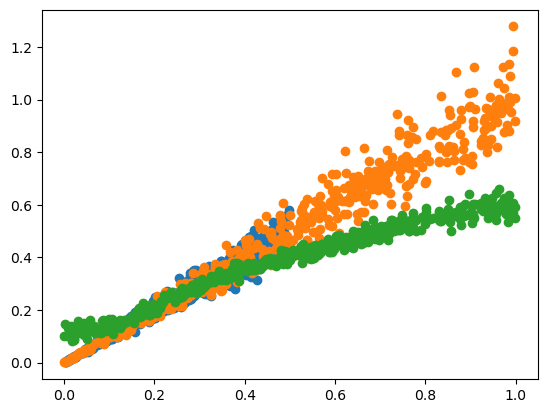

In [27]:
plt.scatter(Xs[:,0], Ys[:,0])
plt.scatter(new_Xs[:,0], new_Ys[:,0])
plt.scatter(new_Xs[:,0], test_mean[:,0])
plt.show()